# 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# 2. Load Dataset

In [2]:
df = pd.read_csv('../datasets/Heart_failure_clinical_records_dataset.csv')

## Cek data sekilas

In [3]:
print("Data Shape:", df.shape)
display(df.head())

Data Shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# 3. Preprocessing (Memisahkan Fitur dan Target)
Target adalah 'DEATH_EVENT' (1 = Meninggal, 0 = Bertahan)

In [4]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

## Split Data (80% Training, 20% Testing)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Scaling

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Training Model (Logistic Regression)

In [7]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

# 5. Evaluasi Model

In [8]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

In [9]:
print(f"\n=== Model Accuracy: {accuracy:.2%} ===\n")
print(classification_report(y_test, y_pred))


=== Model Accuracy: 80.00% ===

              precision    recall  f1-score   support

           0       0.76      0.97      0.85        35
           1       0.93      0.56      0.70        25

    accuracy                           0.80        60
   macro avg       0.84      0.77      0.77        60
weighted avg       0.83      0.80      0.79        60



# Visualisasi Confusion Matrix (Bukti untuk Laporan/Video SC6)

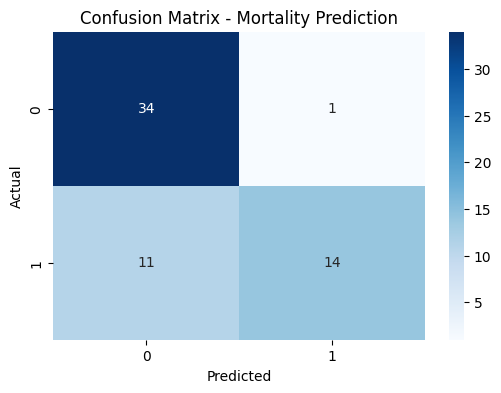

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Mortality Prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../output/confusion_matrix.png') # Simpan gambar otomatis
plt.show()

# 6. EKSTRAKSI RUMUS (PENTING UNTUK WEBSITE)
Ambil Koefisien (Bobot) dan Intercept

In [11]:
coefficients = model.coef_[0]
intercept = model.intercept_[0]
feature_names = X.columns

print("\n" + "="*50)
print("RUMUS UNTUK JAVASCRIPT (Simpan Angka Ini!)")
print("="*50)
print("Konstanta (Intercept):", intercept)
print("\nBobot per Fitur:")
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

print("\nMean (Rata-rata) untuk Scaler:")
print(list(scaler.mean_))
print("\nScale (Standar Deviasi) untuk Scaler:")
print(list(scaler.scale_))


RUMUS UNTUK JAVASCRIPT (Simpan Angka Ini!)
Konstanta (Intercept): -1.6207563619567413

Bobot per Fitur:
age: 0.6614
anaemia: -0.0519
creatinine_phosphokinase: 0.1107
diabetes: 0.1645
ejection_fraction: -0.8766
high_blood_pressure: -0.0604
platelets: -0.1694
serum_creatinine: 0.7020
serum_sodium: -0.2604
sex: -0.3628
smoking: 0.0716
time: -1.6512

Mean (Rata-rata) untuk Scaler:
[np.float64(61.064158995815895), np.float64(0.4351464435146444), np.float64(577.0836820083682), np.float64(0.40585774058577406), np.float64(38.26359832635983), np.float64(0.3514644351464435), np.float64(262427.45020920504), np.float64(1.3873640167364019), np.float64(136.418410041841), np.float64(0.6443514644351465), np.float64(0.3138075313807531), np.float64(132.29707112970712)]

Scale (Standar Deviasi) untuk Scaler:
[np.float64(11.98137291466746), np.float64(0.4957761755179456), np.float64(944.95435750474), np.float64(0.49105726243726866), np.float64(11.626760595602065), np.float64(0.4774276761705745), np.float